In [1]:
# menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# memanggil data set lewat gdrive
path = "/content/drive/MyDrive/Machine_Learning/Praktikum5/data"

In [3]:
#Membaca data csv
import pandas as pd
df = pd.read_csv(path + "/Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# Melihat informasi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
# Cek missing value
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [7]:
# Cek Duplikate
df.duplicated().sum()

np.int64(0)

In [10]:
# Mengubah nama kolom
df = df.rename(columns={
    'SepalLengthCm': 'panjangsepal_cm',
    'SepalWidthCm': 'lebarsepal_cm',
    'PetalLengthCm': 'panjangpetal_cm',
    'PetalWidthCm': 'lebarpetal_cm',
    'Species': 'jenis_bunga'
})

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               150 non-null    int64  
 1   panjangsepal_cm  150 non-null    float64
 2   lebarsepal_cm    150 non-null    float64
 3   panjangpetal_cm  150 non-null    float64
 4   lebarpetal_cm    150 non-null    float64
 5   jenis_bunga      150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


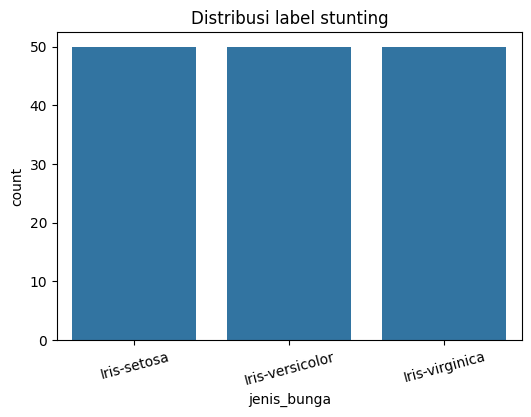

In [11]:
# Data Understanding (Exploratory Data Analysis)

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
sns.countplot(x='jenis_bunga', data=df)
plt.title('Distribusi label stunting')
plt.xticks(rotation=15)
plt.show()

In [12]:
# mapping label -> kode untuk target
bunga_cat = df['jenis_bunga'].astype('category')
bunga_classes = list(bunga_cat.cat.categories)
df['jenis_bunga'] = bunga_cat.cat.codes

df.head()


,Id,panjangsepal_cm,lebarsepal_cm,panjangpetal_cm,lebarpetal_cm,jenis_bunga
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


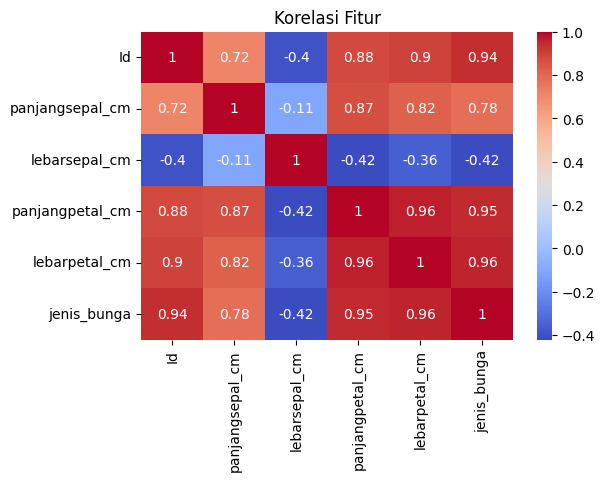

In [13]:
# Korelasi
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Korelasi Fitur')
plt.show()

In [14]:
# SPliting data
# Memilihfitur dan target
feature_cols = ['panjangsepal_cm', 'lebarsepal_cm', 'panjangpetal_cm', 'lebarpetal_cm']
X = df[feature_cols]
y = df['jenis_bunga']

In [15]:
# Membagi dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

len(X_train), len(X_test)

(120, 30)

In [16]:
#Membangun model
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [18]:
# Evaluasi
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

y_pred = dt.predict(X_test)
print("Akurasi:",  round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred, target_names=bunga_classes
    ))


Akurasi: 93.33 %

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



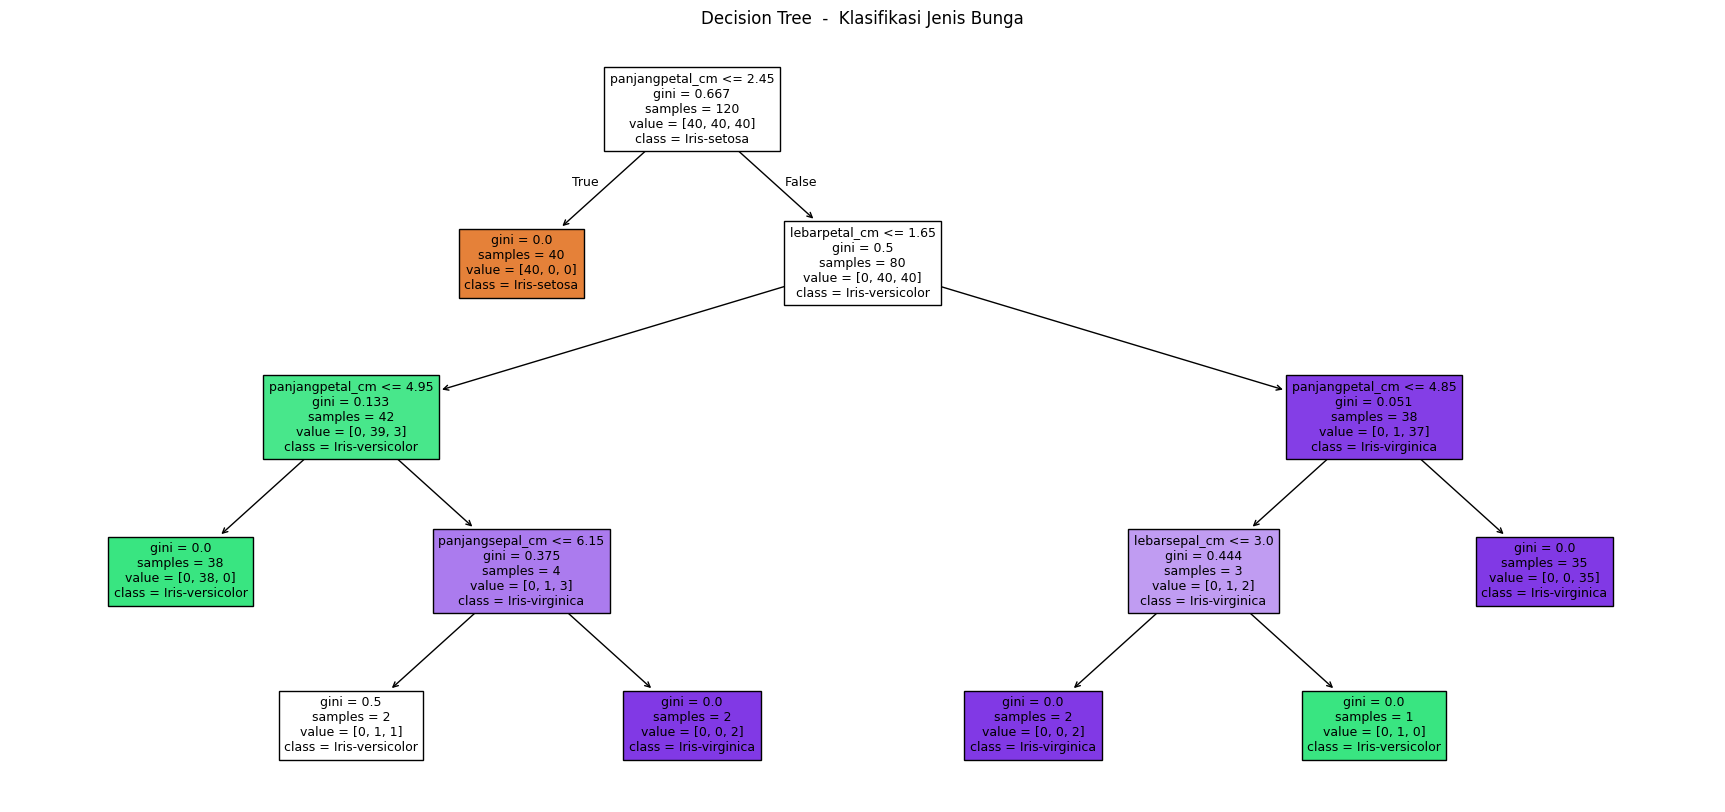

In [23]:
# Visualisasi model
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=bunga_classes,
    filled=True,
    fontsize=9
)
plt.title("Decision Tree  -  Klasifikasi Jenis Bunga")
plt.show()

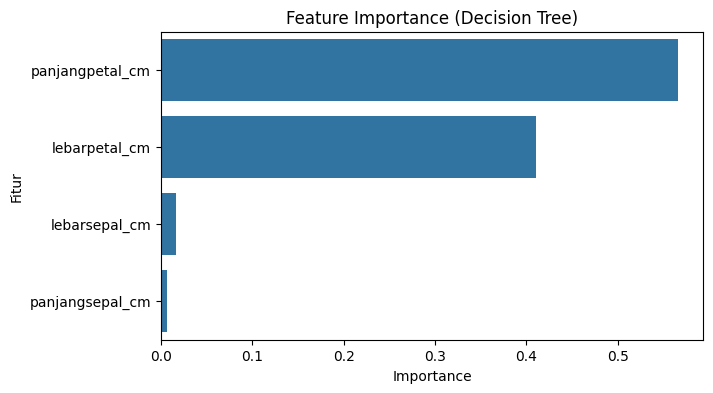

In [21]:
# Fitur yang penting
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
imp = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=imp, y=imp.index)
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.show()

In [22]:
# Hyperparameter Tuning
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
scores = {}
for d in range(2, nine :=9):
  m = DecisionTreeClassifier(max_depth=d, random_state=42)
  m.fit(X_train, y_train)
  scores[d] = accuracy_score(y_test, m.predict(X_test))

  scores
  best_d = max(scores, key=scores.get)
  print("Best max_depth:", best_d, "| Acc:", round(scores[best_d]*100,2), "%")


Best max_depth: 2 | Acc: 93.33 %
Best max_depth: 3 | Acc: 96.67 %
Best max_depth: 3 | Acc: 96.67 %
Best max_depth: 3 | Acc: 96.67 %
Best max_depth: 3 | Acc: 96.67 %
Best max_depth: 3 | Acc: 96.67 %
Best max_depth: 3 | Acc: 96.67 %
